# Семинар. Профилирование, оптимизация, векторизация и Numba

Ноутбук основан на материалах лекции по теме «Лекция 8: Оптимизация выполнения кода, векторизация, Numba»

## Правила
1. В начале ноутбука задаётся `STUDENT_ID
2. Для каждого задания необходимо оставить код, результат выполнения и краткий вывод, если это явно требуется в формулировке.`3.  Работа принимается только при наличии:    
- кода;    
- результатов запуска на локальной машине;    
- таблиц времени выполнения;    
- контрольных сумм;    
- кратких интерпретаций результатов..

In [ ]:
# Впишите свой идентификатор свой идентификатор.
STUDENT_ID = "123456" # например: "123456" из "123456@edu.fa.ru"

In [ ]:
import sys
import os
import math
import time
import json
import hashlib
import statistics
import cProfile
import pstats
import io
from dataclasses import dataclass

import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    import numba
    from numba import njit, vectorize, guvectorize
    NUMBA_AVAILABLE = True
except Exception as exc:
    NUMBA_AVAILABLE = False
    numba = None
    njit = vectorize = guvectorize = None
    print("Numba недоступна. Для заданий 19-20 установите numba. Ошибка:", repr(exc))


def stable_seed(text: str) -> int:
    """Детерминированное получение seed из строки."""
    digest = hashlib.blake2b(text.encode("utf-8"), digest_size=8).hexdigest()
    return int(digest, 16) % (2**32)


SEED = stable_seed(STUDENT_ID)
rng = np.random.default_rng(SEED)
print("STUDENT_ID:", STUDENT_ID)
print("SEED:", SEED)

STUDENT_ID: 123456
SEED: 163630270


In [ ]:
def variant_int(name: str, low: int, high: int) -> int:
    """Индивидуальное целое число из диапазона [low, high]."""
    local_seed = stable_seed(STUDENT_ID + "::" + name)
    return low + local_seed % (high - low + 1)


def variant_float(name: str, low: float, high: float) -> float:
    """Индивидуальное вещественное число из диапазона [low, high)."""
    local_rng = np.random.default_rng(stable_seed(STUDENT_ID + "::" + name))
    return float(local_rng.uniform(low, high))


def fingerprint(obj) -> str:
    """Короткая контрольная сумма объекта, пригодная для отчёта."""
    payload = json.dumps(obj, ensure_ascii=False, sort_keys=True, default=str).encode("utf-8")
    return hashlib.blake2b(payload, digest_size=8).hexdigest()


def normalize_title(s: str) -> str:
    """Нормализация названия для поиска дублей."""
    return " ".join(str(s).casefold().strip().split())


def make_title_dataset(seed: int):
    """Генерирует список псевдоназваний фильмов с дубликатами и шумом регистра/пробелов."""
    local_rng = np.random.default_rng(seed + 101)
    left = np.array([
        "Silent", "Red", "Blue", "Hidden", "Last", "First", "Lost", "Bright",
        "Dark", "Golden", "Iron", "Crystal", "Northern", "Electric", "Broken",
        "Rapid", "Deep", "Furious", "Gentle", "Quantum", "Vector", "Matrix"
    ])
    right = np.array([
        "River", "Forest", "City", "Planet", "Signal", "Dream", "Code", "Memory",
        "Storm", "Machine", "Garden", "Bridge", "Orbit", "Echo", "Archive",
        "Triangle", "Kernel", "Window", "Feature", "Gradient", "Loop", "Cache"
    ])
    n_base = variant_int("n_titles", 2200, 3200)
    n_dups = variant_int("n_dups", 60, 110)

    years = local_rng.integers(1980, 2028, size=n_base)
    ids = local_rng.integers(0, 1_000_000, size=n_base)
    base = [
        f"{local_rng.choice(left)} {local_rng.choice(right)} {y} #{i % 997}"
        for i, y in zip(ids, years)
    ]

    dup_indices = local_rng.choice(np.arange(n_base), size=n_dups, replace=False)
    noisy_dups = []
    for idx in dup_indices:
        title = base[int(idx)]
        mode = int(local_rng.integers(0, 4))
        if mode == 0:
            title = title.upper()
        elif mode == 1:
            title = title.lower()
        elif mode == 2:
            title = "  " + title + "   "
        else:
            title = " ".join(title.split())
        noisy_dups.append(title)

    titles = base + noisy_dups
    local_rng.shuffle(titles)
    return titles


def make_numeric_datasets(seed: int):
    """Генерирует численные массивы для заданий по векторизации и Numba."""
    local_rng = np.random.default_rng(seed + 202)
    n = variant_int("matrix_n", 450, 600)
    arr2d = local_rng.normal(loc=0.5, scale=2.0, size=(n, n)).astype(np.float64)

    vals_n = variant_int("vals_n", 220_000, 360_000)
    vals = local_rng.integers(0, 10_000_000, size=vals_n, dtype=np.int64)

    x = local_rng.normal(size=variant_int("poly_n", 50_000, 90_000)).astype(np.float64)
    coeffs = local_rng.normal(size=variant_int("poly_degree", 4, 7)).astype(np.float64)

    dot_rows = variant_int("dot_rows", 1200, 2200)
    dot_dim = variant_int("dot_dim", 5, 9)
    X = local_rng.normal(size=(dot_rows, dot_dim)).astype(np.float64)
    w = local_rng.normal(size=dot_dim).astype(np.float64)

    batch = variant_int("batch", 600, 1200)
    A = local_rng.normal(size=(batch, 3, 4)).astype(np.float64)
    b = local_rng.normal(size=(batch, 4)).astype(np.float64)

    signals = local_rng.normal(size=(variant_int("signals_m", 250, 450), 180)).astype(np.float64)
    return {
        "arr2d": arr2d,
        "vals": vals,
        "x": x,
        "coeffs": coeffs,
        "X": X,
        "w": w,
        "A": A,
        "b": b,
        "signals": signals,
    }


titles = make_title_dataset(SEED)
data = make_numeric_datasets(SEED)

variant_meta = {
    "student_id": STUDENT_ID,
    "seed": SEED,
    "n_titles": len(titles),
    "arr2d_shape": data["arr2d"].shape,
    "vals_shape": data["vals"].shape,
    "poly_degree": len(data["coeffs"]) - 1,
    "dot_shape": data["X"].shape,
    "batch_shape": data["A"].shape,
    "signals_shape": data["signals"].shape,
}
print(json.dumps(variant_meta, ensure_ascii=False, indent=2))
print("variant_fingerprint:", fingerprint(variant_meta))

{
  "student_id": "123456",
  "seed": 163630270,
  "n_titles": 2887,
  "arr2d_shape": [
    498,
    498
  ],
  "vals_shape": [
    298080
  ],
  "poly_degree": 5,
  "dot_shape": [
    1266,
    7
  ],
  "batch_shape": [
    802,
    3,
    4
  ],
  "signals_shape": [
    334,
    180
  ]
}
variant_fingerprint: 631583d8fd003c02


## Задание 1. Бенчмарк

In [ ]:
def benchmark(func, *args, repeats=5, warmups=1, **kwargs):
    # ВАШ КОД

# ВАШ КОД: проверить работу benchmark на sum(range(1000))

{'best': 1.2099999366910197e-05,
 'mean': 1.2766666865597168e-05,
 'std': 5.312462698678133e-07,
 'runs': [1.340000017080456e-05,
  1.2800001059076749e-05,
  1.2099999366910197e-05]}

## Задание 2. Проверки корректности

In [ ]:
def assert_equal(a, b, msg=""):
    # ВАШ КОД


def assert_allclose(a, b, rtol=1e-9, atol=1e-9, msg=""):
   # ВАШ КОД

# ВАШ КОДO: добавить 2-3 проверки

Проверки работают


## Задание 3. Базовый поиск дубликатов за квадратичное время

In [ ]:
def find_duplicates_slow(titles):
    # ВАШ КОД

# ВАШ КОД: запустить benchmark и вывести результат

duplicates_count: 70
first_5: ['blue bridge 2021 #636', 'blue dream 1998 #722', 'blue echo 2016 #789', 'blue feature 2003 #218', 'blue machine 1982 #115']
time: {'best': 1.3010821999996551, 'mean': 1.3010821999996551, 'std': 0.0, 'runs': [1.3010821999996551]}
result_fingerprint: 5d877a0d6f33bf8f


## Задание 4. Профилирование базового поиска дубликатов

В отчёте обычно видно, что основное время уходит на многократные вызовы нормализации и вложенный просмотр списка. Это типичный случай, где сначала нужно менять алгоритм и структуру данных, а не только синтаксис.

In [ ]:
def profile_top(func, *args, limit=12, sort_by="cumulative", **kwargs):
    # ВАШ КОД

# ВАШ КОД: получить и вывести отчёт профилирования

         20175297 function calls (20175293 primitive calls) in 5.297 seconds

   Ordered by: cumulative time
   List reduced from 122 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    5.223    2.612 C:\ProgramData\anaconda3\Lib\asyncio\base_events.py:1910(_run_once)
        2    0.000    0.000    5.223    2.612 C:\ProgramData\anaconda3\Lib\asyncio\windows_events.py:443(select)
        1    0.565    0.565    5.223    5.223 C:\Users\efboltachev\AppData\Local\Temp\ipykernel_10424\3606642726.py:1(find_duplicates_slow)
  4034378    2.509    0.000    4.727    0.000 C:\Users\efboltachev\AppData\Local\Temp\ipykernel_10424\146788215.py:19(normalize_title)
  4034378    0.817    0.000    0.817    0.000 {method 'split' of 'str' objects}
  4034378    0.596    0.000    0.596    0.000 {method 'join' of 'str' objects}
  4034378    0.458    0.000    0.458    0.000 {method 'casefold' of 'str' objects}
  4034378    0.348 

## Задание 5. Первая оптимизация: вынести нормализацию из внутреннего цикла

In [ ]:
def find_duplicates_precomputed(titles):
    # ВАШ КОД

# ВАШ КОД: проверить корректность и измерить ускорение

slow_time_best: 1.3010821999996551
precomputed_time: {'best': 0.06551579999904789, 'mean': 0.06551579999904789, 'std': 0.0, 'runs': [0.06551579999904789]}
speedup: 19.85905995223386


## Задание 6. Вторая оптимизация: алгоритм на основе множества

Здесь основное ускорение достигается не за счёт JIT или NumPy, а за счёт перехода от вложенного поиска к хеш-таблице.

In [ ]:
def find_duplicates_set(titles):
    # ВАШ КОД

# ВАШ КОД: проверить корректность и измерить ускорение

precomputed_speedup: 56.57668397986437
slow_speedup: 1123.5597590547156
set_time: {'best': 0.0011579999991226941, 'mean': 0.0012309857143658778, 'std': 8.608964517411058e-05, 'runs': [0.0013834000001224922, 0.001268900001377915, 0.0011644000005617272, 0.0013192000005801674, 0.0011588999986997806, 0.0011579999991226941, 0.0011641000000963686]}


## Задание 7. Эксперимент по сложности алгоритмов

,n,slow,precomputed,set
0,300,0.014905,0.000928,0.000114
1,600,0.059042,0.003126,0.000233
2,1200,0.232764,0.011452,0.000465
3,2400,0.889200,0.044434,0.000867


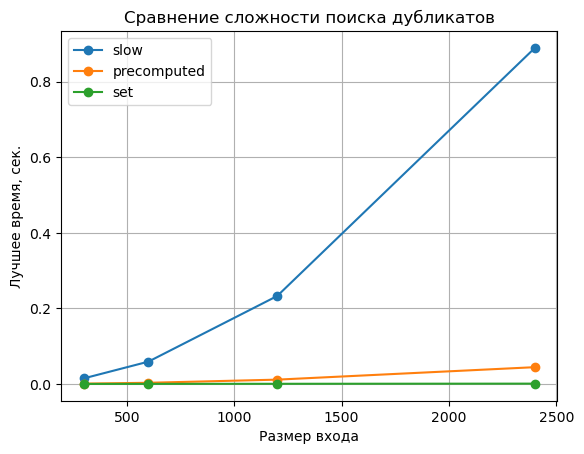

In [ ]:
# ВАШ КОД: провести эксперимент по размерам входа

## Задание 8. Сумма квадратов матрицы: чистый Python

In [ ]:
def sum_sq_2d_py(arr):
    # ВАШ КОД

# ВАШ КОД: запустить на data["arr2d"]

sum_py: 1052546.5951200877
fingerprint: 64441f3fdb09057b
time: {'best': 0.03163920000042708, 'mean': 0.03163920000042708, 'std': 0.0, 'runs': [0.03163920000042708]}


## Задание 9. Сумма квадратов матрицы: NumPy-векторизация

Выражение `arr * arr` создаёт временный массив такого же размера, как `arr`. Это быстро, потому что цикл выполняется в оптимизированном коде NumPy, но может быть не лучшим вариантом по памяти.

In [ ]:
def sum_sq_2d_numpy(arr):
    # ВАШ КОД

# ВАШ КОД: проверить корректность и измерить ускорение

sum_np: 1052546.595120104
time: {'best': 0.0005737999999837484, 'mean': 0.0007281285717389048, 'std': 0.00021373521467718813, 'runs': [0.0009618000003683846, 0.0005737999999837484, 0.0006069000010029413, 0.0005772999993496342, 0.000641800001176307, 0.0005870000004506437, 0.001148299999840674]}
speedup: 55.13976995699406


## Задание 10. Сумма квадратов без лишнего временного массива

`np.einsum("ij,ij->", arr, arr)` и `np.dot(arr.ravel(), arr.ravel())` позволяют выразить свёртку без явного создания массива `arr * arr` на уровне Python-выражения.

In [ ]:
def sum_sq_2d_einsum(arr):
    # ВАШ КОД

# ВАШ КОД: сравнить три реализации

,method,best_sec
0,python loops,0.031639
1,np.sum(arr * arr),0.000574
2,np.einsum,0.000068
